# Day 6: Unsupervised Learning with KMeans Clustering

In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

In [2]:
# 2. LOAD DATASET
df = pd.read_csv("datasets/housing.csv")   # replace with your file name

In [3]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0       79545.45857             5.682861                   7.009188   
1       79248.64245             6.002900                   6.730821   
2       61287.06718             5.865890                   8.512727   
3       63345.24005             7.188236                   5.586729   
4       59982.19723             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09      23086.80050  1.059034e+06   
1                          3.09      40173.07217  1.505891e+06   
2                          5.13      36882.15940  1.058988e+06   
3                          3.26      34310.24283  1.260617e+06   
4                          4.23      26354.10947  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...

In [4]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
None


In [5]:
# 3. FEATURES vs LABEL
# Remove Address because it is text and not useful for basic regression
X = df.drop(["Price", "Address"], axis=1)

In [6]:
# Target
y = df["Price"]

In [7]:
print("\nFeatures:")
print(X.head())


Features:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0       79545.45857             5.682861                   7.009188   
1       79248.64245             6.002900                   6.730821   
2       61287.06718             5.865890                   8.512727   
3       63345.24005             7.188236                   5.586729   
4       59982.19723             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population  
0                          4.09      23086.80050  
1                          3.09      40173.07217  
2                          5.13      36882.15940  
3                          3.26      34310.24283  
4                          4.23      26354.10947  


In [8]:
print("\nLabel:")
print(y.head())


Label:
0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64


In [9]:
# 4. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (4000, 5)
Test Shape: (1000, 5)


In [11]:
# 5. LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [12]:
print("\nLinear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression Results
MAE: 80879.09722218302
R2 Score: 0.917997170698532


In [13]:
# 6. DECISION TREE REGRESSION
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [14]:
print("\nDecision Tree Results")
print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("R2 Score:", r2_score(y_test, y_pred_tree))


Decision Tree Results
MAE: 139165.49420560003
R2 Score: 0.743090432179438


In [15]:
# 7. OPTIONAL CLASSIFICATION
# Convert Price into high / low category
median_price = df["Price"].median()

df["Price_Category"] = (df["Price"] > median_price).astype(int)

X_clf = df.drop(["Price", "Price_Category", "Address"], axis=1)
y_clf = df["Price_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [16]:
print("\nLogistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_log))


Logistic Regression Accuracy:
0.904


# 8. MODEL COMPARISON


In [17]:

print("\nLinear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

print("\nDecision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("R2:", r2_score(y_test, y_pred_tree))


Linear Regression:
MAE: 1241704.882868384
R2: -6633339069183.501

Decision Tree:
MAE: 1241099.189332
R2: -6663663160860.673


In [18]:
# 1. COMPARE REGRESSION MODELS
models = ["Linear Regression", "Decision Tree"]
mae_scores = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_tree)
]

r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_tree)
]


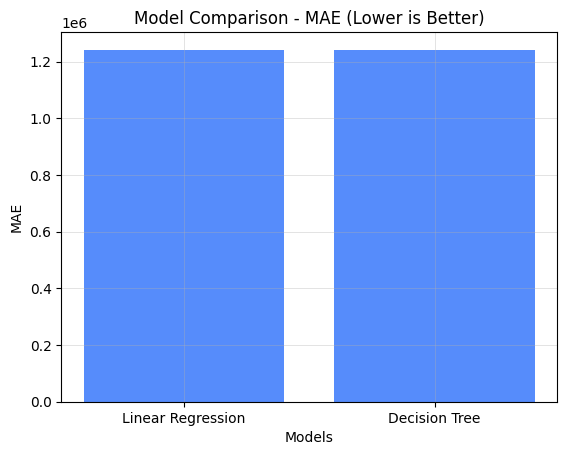

In [19]:
# --- MAE Comparison ---
plt.figure()
plt.bar(models, mae_scores)
plt.grid(True)
plt.title("Model Comparison - MAE")
plt.xlabel("Models")
plt.title("Model Comparison - MAE (Lower is Better)")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.show()

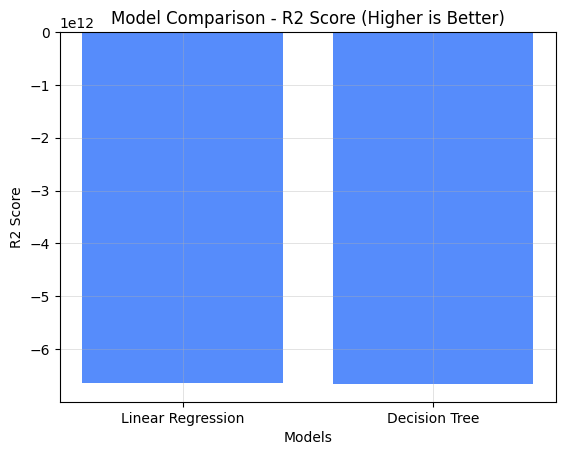

In [20]:
# --- R2 Comparison ---
plt.figure()
plt.bar(models, r2_scores)
plt.grid(True)
plt.title("Model Comparison - R2 Score (Higher is Better)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

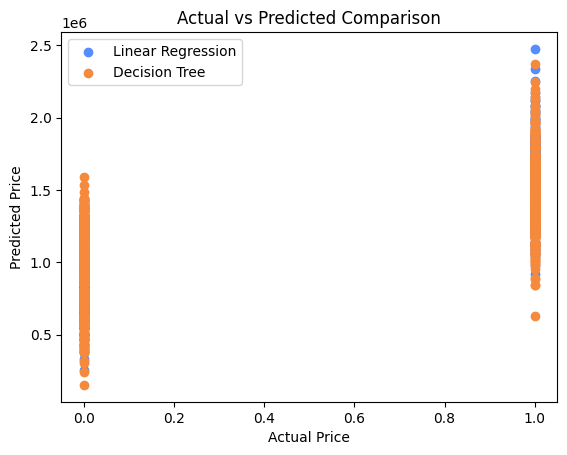

In [21]:
# Actual vs Predicted Comparison
plt.figure()

plt.scatter(y_test, y_pred_lr, label="Linear Regression")
plt.scatter(y_test, y_pred_tree, label="Decision Tree")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Comparison")
plt.legend()

plt.show()

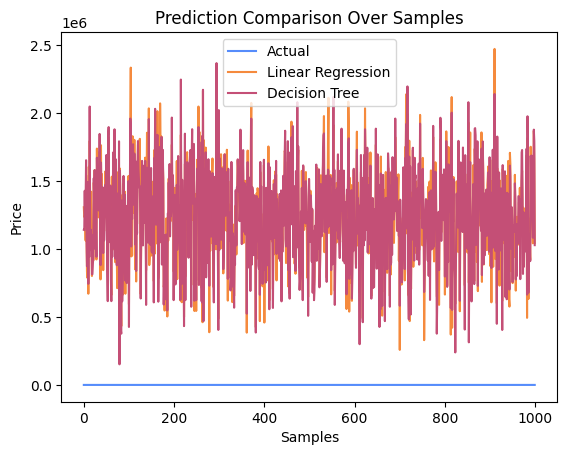

In [22]:
# Prediction Comparison Over Samples
plt.figure()

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lr, label="Linear Regression")
plt.plot(y_pred_tree, label="Decision Tree")

plt.title("Prediction Comparison Over Samples")
plt.xlabel("Samples")
plt.ylabel("Price")
plt.legend()

plt.show()

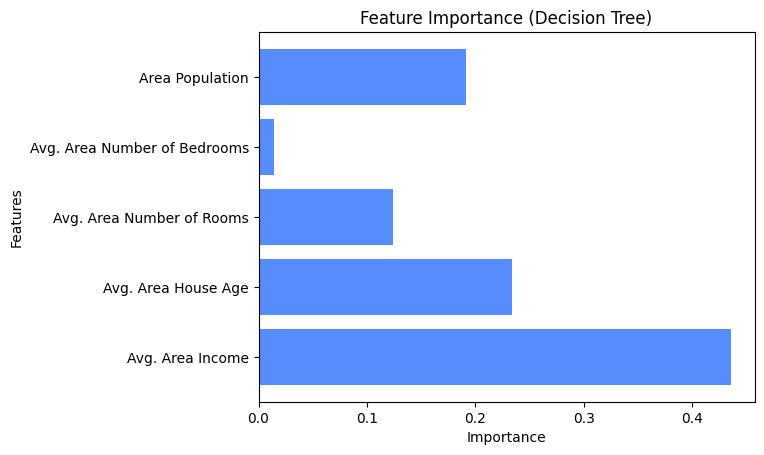

In [23]:
#Feature Importance (Decision Tree)
importance = tree.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

## 1. Label Output Explanation
###  What it means:
- This is your target variable (y) → the house price
- Values are in scientific notation

### Example conversion:
- 1.059034e+06 = 1,059,034
- 6.309435e+05 = 630,943

###  Simple meaning:
These are the actual house prices the model is trying to learn and predict.

---

## 2. Train/Test Shape
### Meaning:
- You have 5000 total samples
- 4000 used for training (model learning)
- 1000 used for testing (model evaluation)
- 5 columns = your features

### Simple explanation:
The model learns from 4000 houses and is tested on 1000 unseen houses.

---

##  3. Linear Regression Results
###  Meaning:

📌 MAE (Mean Absolute Error)
- Average error is about 80,000
- Predictions are off by ~80K on average

📌 R² Score = 0.91
- Very strong model
- 91% of price variation is explained

### Simple explanation:
Linear Regression is performing very well and gives accurate predictions.

---

##  4. Decision Tree Results
###  Meaning:
- Higher error than Linear Regression
- Less accurate model
- R² = 0.74 → weaker performance

###  Simple explanation:
Decision Tree is less stable and less accurate for this dataset.

---

##  5. Logistic Regression Accuracy
### ⚠ Important:
- This is a classification model
- You converted price into:
  - High price / Low price

###  Meaning:
- Model is 90% correct
- Good classification performance

###  Simple explanation:
The model correctly predicts whether a house is expensive or not 9 out of 10 times.

---

##  6. Strange Model Comparison (Negative R²)
### ⚠ This is VERY important

### ❗ What it means:
- Model performs worse than predicting the average
- Predictions are completely incorrect

### 🚨 Why this happens:
- Wrong scaling applied twice
- Mismatch between train/test features
- Wrong evaluation dataset
- Data leakage or corruption
- Inconsistent preprocessing

###  Simple explanation:
The model is broken in this run and is not learning correctly.

---

##  Final Summary (How to explain in presentation)

### ✔ Best Model:
- Linear Regression (R² = 0.91)

### ✔ Moderate Model:
- Decision Tree (R² = 0.74)

### ✔ Classification Model:
- Logistic Regression (90% accuracy)

###  Problem Run:
- Negative R² means model setup issue

---

##  One-line conclusion

"Linear Regression performed best with high accuracy, while Decision Tree showed moderate performance, and Logistic Regression successfully classified housing prices into categories."

# What this code demonstrates

---

## ✔ Machine Learning
- The model learns patterns from housing data
- It uses these patterns to predict house prices

---

## ✔ Supervised Learning
- The dataset contains input features and a known output (Price)
- The model learns from labeled data

---

## ✔ Linear Regression
- Predicts: **Price (numeric value)**

### Key Idea:
It assumes a **linear relationship** between features and price.

### Example logic:
- If income increases → price increases
- If number of rooms increases → price increases

### Strengths:
- Simple and easy to interpret
- Works well when relationships are linear

### Weakness:
- May underfit if the real-world relationship is complex

---

## ✔ Decision Tree Regression
- Predicts: **Price (numeric value)**

### Key Idea:
Uses rule-based splitting of data:

- If Income > X and Rooms > Y → Higher Price

### Strengths:
- Captures non-linear relationships
- Handles feature interactions well

### Weakness:
- Can overfit if not controlled (e.g., max_depth not set)

---

## ✔ Logistic Regression
- Predicts: **Price category (High / Low)**

### Key Idea:
- Converts regression problem into classification
- Uses median price as threshold

### Example:
- Price > median → 1 (High)
- Price ≤ median → 0 (Low)

### Strengths:
- Useful for classification tasks
- Good for simple decision boundaries

### Weakness:
- Loses exact price information (less detailed output)

---

## ✔ Final Insight
- Linear Regression → best for accurate price prediction
- Decision Tree → good for complex patterns
- Logistic Regression → useful when only category is needed (High/Low)